# 02 — Feature Engineering

This notebook constructs and validates the full feature matrix used by the survival model.

**Pipeline position:** Raw API → EDA → **Feature Engineering** → Model Training

Features are grouped into three families:
1. **Technical** — RSI, Bollinger Bands, MACD, ATR, VWAP
2. **Volatility & Tail Risk** — Realized vol, Garman-Klass, Downside deviation, Max drawdown
3. **Microstructure** — Volume ratio, buy/sell pressure, funding rate z-score

In [10]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from src.ingestion.collector import DataCollector
from src.features.pipeline import build_features, FEATURE_COLS
from src.models.survival import label_events, EVENT_THRESHOLD, DURATION_WINDOW

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3,
})
SYMBOLS = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT']
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

## 1. Collect & Build Feature Matrix

In [11]:
# Jupyter runs its own event loop — use await directly instead of asyncio.run()
async with DataCollector() as c:
    snapshots = await c.collect_all(SYMBOLS)

df_klines = DataCollector.snapshots_to_kline_df(snapshots)
funding_rates = {
    snap.symbol: [f.model_dump() for f in snap.funding_rates]
    for snap in snapshots
}

df = build_features(df_klines, funding_rates)
print(f'Feature matrix: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Model features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
df[FEATURE_COLS].describe().round(4)

2026-04-26 16:16:02 [info     ] collect_all_start              symbols=['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT']
2026-04-26 16:16:02 [info     ] collecting                     symbol=BTCUSDT
2026-04-26 16:16:02 [info     ] collecting                     symbol=ETHUSDT
2026-04-26 16:16:02 [info     ] collecting                     symbol=BNBUSDT
2026-04-26 16:16:02 [info     ] collecting                     symbol=SOLUSDT
2026-04-26 16:16:02 [info     ] collecting                     symbol=XRPUSDT
2026-04-26 16:16:02 [debug    ] binance_spot_request           elapsed=0.10178495792206377 params={'symbol': 'ETHUSDT', 'limit': 20} path=/api/v3/depth
2026-04-26 16:16:02 [debug    ] binance_spot_request           elapsed=0.10132587503176183 params={'symbol': 'BNBUSDT'} path=/api/v3/ticker/24hr
2026-04-26 16:16:02 [debug    ] binance_spot_request           elapsed=0.10695062507875264 params={'symbol': 'BNBUSDT', 'interval': '1h', 'limit': 500} path=/api/v3/klines
2026-04-26 16:

,log_return,rsi_14,bb_width_20,bb_pct_20,macd_hist,atr_pct_14,volume_ratio,vwap_divergence,buy_sell_ratio,realized_vol_24h,realized_vol_168h,downside_dev_24h,max_drawdown_24h,max_drawdown_168h,gk_vol_24h,funding_rate_z
count,1660.0000,1660.0000,1660.0000,1660.0000,1660.0000,1660.0000,1660.0000,1660.0000,1660.0000,1660.0000,1660.0000,1660.0000,1660.0000,1660.0000,1660.0000,1660.0000
mean,0.0002,50.2255,0.0287,0.5221,0.6653,0.0066,0.9993,0.0008,1.0519,0.0813,0.0346,0.0445,-0.0125,-0.0292,0.4278,-0.1547
std,0.0044,16.8849,0.0179,0.3245,48.0512,0.0021,0.6816,0.0101,0.3591,0.0316,0.0073,0.0183,0.0115,0.0174,0.1248,0.9433
min,-0.0162,10.8906,0.0053,-0.2791,-214.0769,0.0021,0.1097,-0.0293,0.2921,0.0225,0.0210,0.0139,-0.0583,-0.0769,0.1304,-3.0309
25%,-0.0021,38.6129,0.0159,0.2625,-0.3861,0.0052,0.5508,-0.0057,0.8125,0.0603,0.0283,0.0329,-0.0187,-0.0434,0.3451,-0.6942
50%,0.0000,50.3719,0.0238,0.5287,0.0006,0.0064,0.8295,0.0005,0.9942,0.0753,0.0334,0.0396,-0.0093,-0.0271,0.4208,-0.2506
75%,0.0021,62.6175,0.0370,0.7824,0.4363,0.0078,1.2111,0.0069,1.2365,0.0980,0.0398,0.0525,-0.0035,-0.0159,0.4993,0.4587
max,0.0402,95.1983,0.1298,1.4028,332.5601,0.0151,6.5522,0.0471,3.6978,0.2026,0.0516,0.1232,0.0000,0.0000,0.7996,3.4275


## 2. Missing Value & Coverage Check

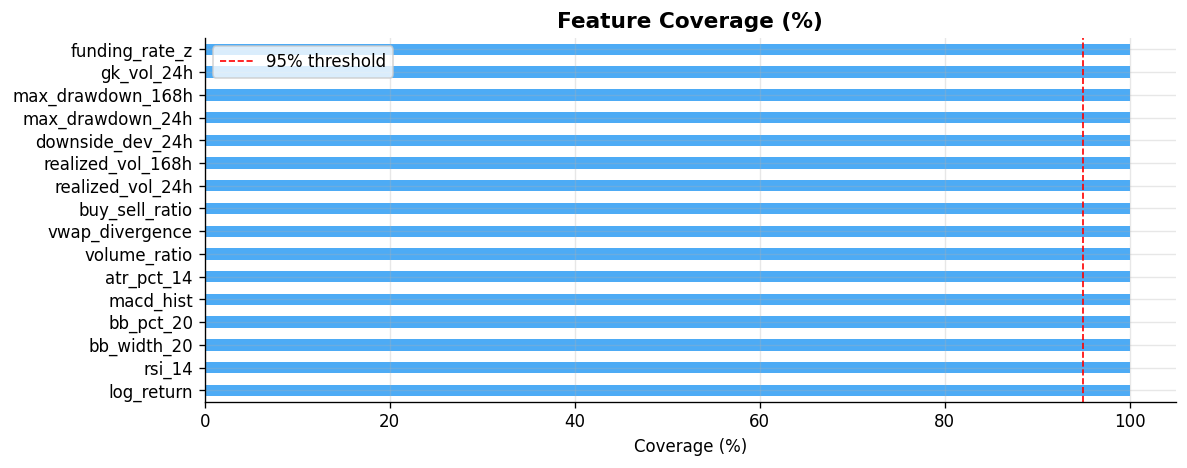

,missing,coverage_%
log_return,0,100.0
rsi_14,0,100.0
bb_width_20,0,100.0
bb_pct_20,0,100.0
macd_hist,0,100.0
atr_pct_14,0,100.0
volume_ratio,0,100.0
vwap_divergence,0,100.0
buy_sell_ratio,0,100.0
realized_vol_24h,0,100.0


In [12]:
missing = df[FEATURE_COLS].isnull().sum()
coverage = (1 - missing / len(df)) * 100

fig, ax = plt.subplots(figsize=(10, 4))
coverage.sort_values().plot(kind='barh', ax=ax, color='#2196F3', alpha=0.8)
ax.axvline(95, color='red', linestyle='--', linewidth=1, label='95% threshold')
ax.set_title('Feature Coverage (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Coverage (%)')
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({'missing': missing, 'coverage_%': coverage.round(1)})

## 3. Technical Indicators — BTC Deep Dive

Visual validation that RSI, Bollinger Bands, and MACD are computed correctly.

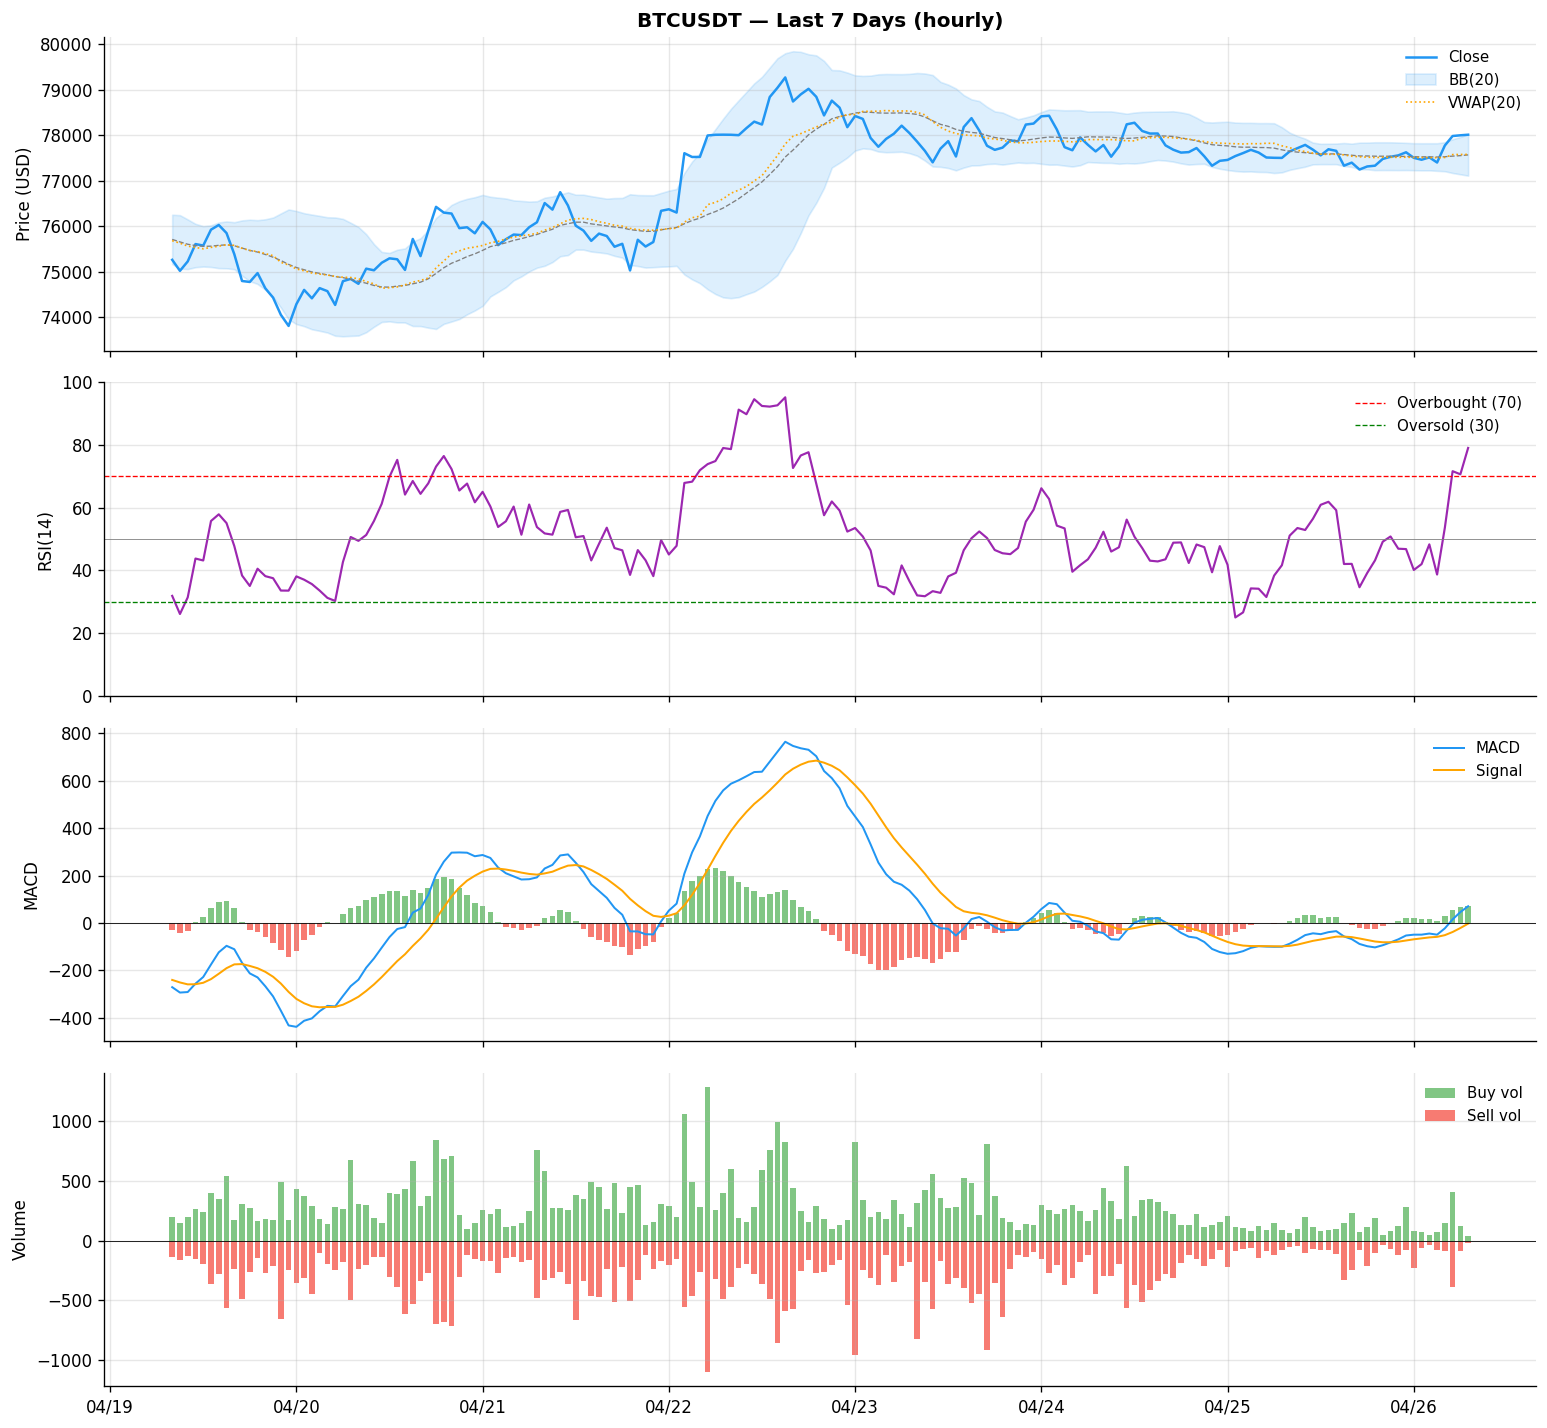

In [13]:
btc = df[df['symbol'] == 'BTCUSDT'].sort_values('open_time').copy()
btc_tail = btc.tail(168)  # last 7 days

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

# Price + Bollinger Bands
ax = axes[0]
ax.plot(btc_tail['open_time'], btc_tail['close'], color='#2196F3', linewidth=1.5, label='Close')
ax.fill_between(btc_tail['open_time'], btc_tail['bb_lower_20'], btc_tail['bb_upper_20'],
                alpha=0.15, color='#2196F3', label='BB(20)')
ax.plot(btc_tail['open_time'], btc_tail['bb_mid_20'], color='gray', linewidth=0.8, linestyle='--')
ax.plot(btc_tail['open_time'], btc_tail['vwap_20'], color='orange', linewidth=1, linestyle=':', label='VWAP(20)')
ax.set_title('BTCUSDT — Last 7 Days (hourly)', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(frameon=False, fontsize=9)

# RSI
ax = axes[1]
ax.plot(btc_tail['open_time'], btc_tail['rsi_14'], color='#9C27B0', linewidth=1.3)
ax.axhline(70, color='red', linestyle='--', linewidth=0.8, label='Overbought (70)')
ax.axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
ax.axhline(50, color='gray', linestyle='-', linewidth=0.5)
ax.set_ylabel('RSI(14)')
ax.set_ylim(0, 100)
ax.legend(frameon=False, fontsize=9)

# MACD
ax = axes[2]
ax.bar(btc_tail['open_time'], btc_tail['macd_hist'],
       color=np.where(btc_tail['macd_hist'] >= 0, '#4CAF50', '#F44336'), alpha=0.7, width=0.03)
ax.plot(btc_tail['open_time'], btc_tail['macd'], color='#2196F3', linewidth=1.2, label='MACD')
ax.plot(btc_tail['open_time'], btc_tail['macd_signal'], color='orange', linewidth=1.2, label='Signal')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('MACD')
ax.legend(frameon=False, fontsize=9)

# Volume
ax = axes[3]
ax.bar(btc_tail['open_time'], btc_tail['taker_buy_base_volume'], color='#4CAF50', alpha=0.7, width=0.03, label='Buy vol')
sell_vol = btc_tail['volume'] - btc_tail['taker_buy_base_volume']
ax.bar(btc_tail['open_time'], -sell_vol, color='#F44336', alpha=0.7, width=0.03, label='Sell vol')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Volume')
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

plt.tight_layout()
plt.show()

## 4. Volatility Features — Multi-Window Comparison

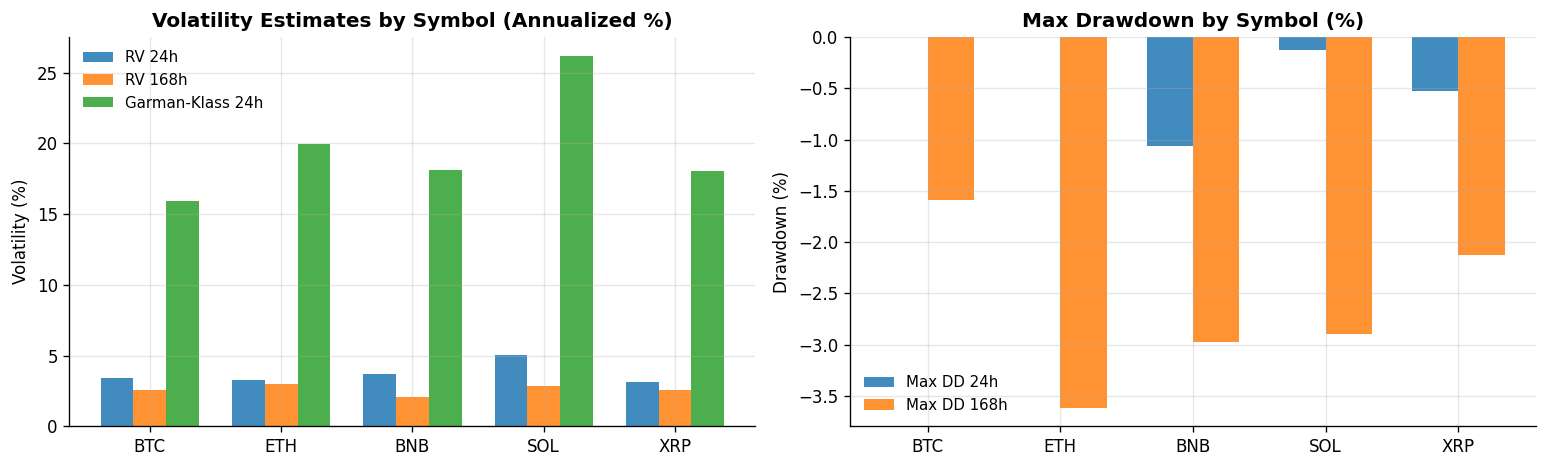

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

latest = df.sort_values('open_time').groupby('symbol').last().reset_index()
vol_cols = ['realized_vol_24h', 'realized_vol_168h', 'gk_vol_24h']
vol_labels = ['RV 24h', 'RV 168h', 'Garman-Klass 24h']

x = np.arange(len(SYMBOLS))
width = 0.25
ax = axes[0]
for i, (col, label) in enumerate(zip(vol_cols, vol_labels)):
    vals = [latest[latest['symbol'] == s][col].values[0] * 100 if col in latest.columns else 0
            for s in SYMBOLS]
    ax.bar(x + i * width, vals, width, label=label, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels([s.replace('USDT', '') for s in SYMBOLS])
ax.set_title('Volatility Estimates by Symbol (Annualized %)', fontweight='bold')
ax.set_ylabel('Volatility (%)')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
dd_cols = ['max_drawdown_24h', 'max_drawdown_168h']
dd_labels = ['Max DD 24h', 'Max DD 168h']
for i, (col, label) in enumerate(zip(dd_cols, dd_labels)):
    vals = [latest[latest['symbol'] == s][col].values[0] * 100 if col in latest.columns else 0
            for s in SYMBOLS]
    ax.bar(x + i * 0.35, vals, 0.35, label=label, alpha=0.85)
ax.set_xticks(x + 0.175)
ax.set_xticklabels([s.replace('USDT', '') for s in SYMBOLS])
ax.set_title('Max Drawdown by Symbol (%)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

## 5. Feature Correlation Heatmap

High inter-feature correlation can cause multicollinearity in Cox PH.  
The L2 penalizer (`penalizer=0.1`) handles this, but it's worth inspecting.

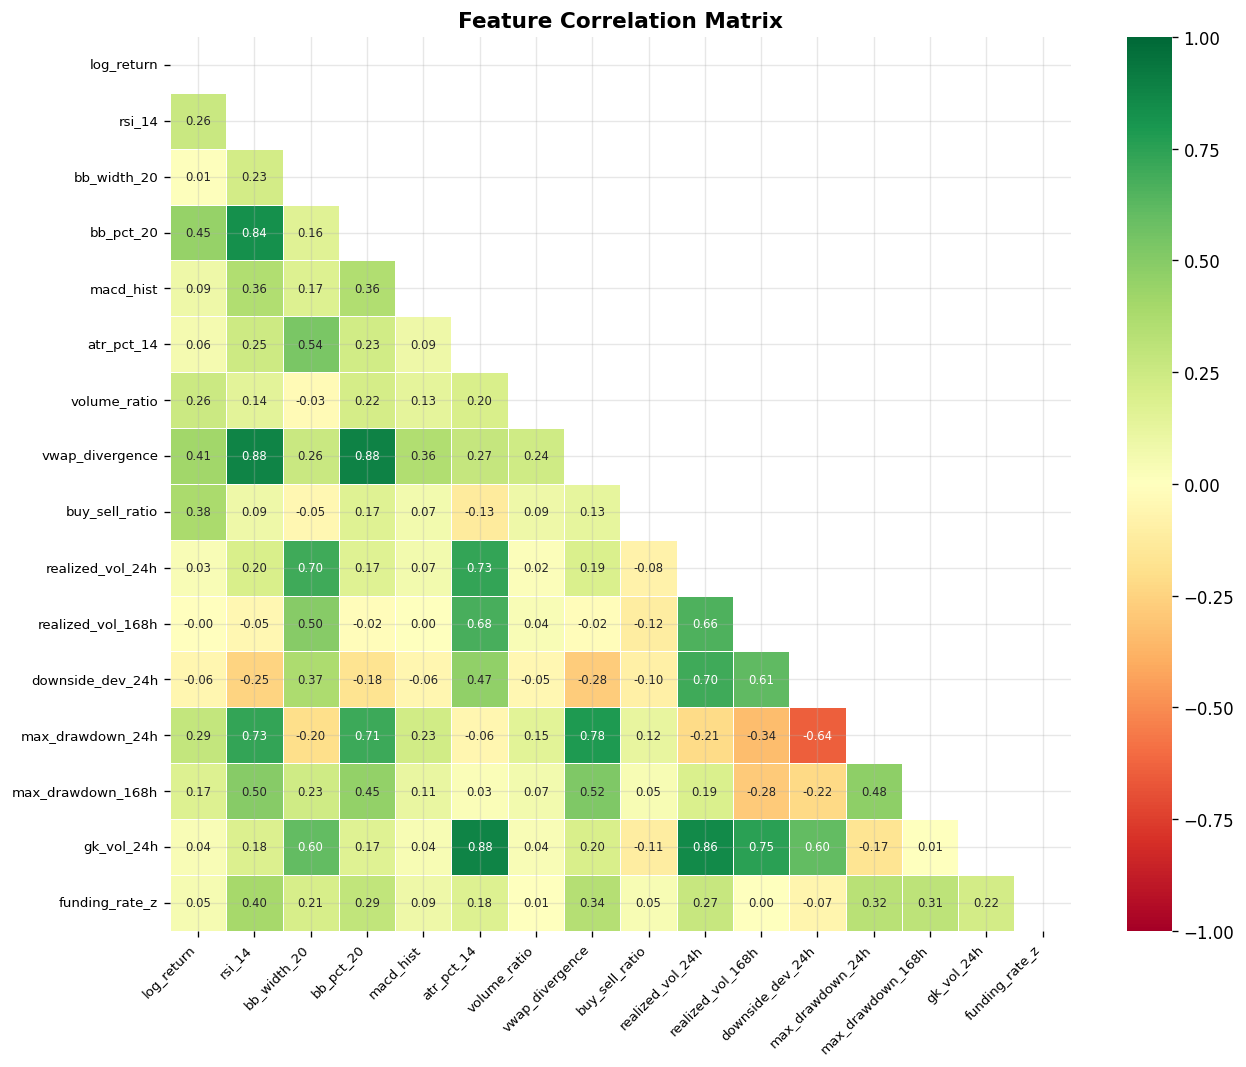

In [15]:
available_features = [c for c in FEATURE_COLS if c in df.columns]
corr_matrix = df[available_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.3, annot_kws={'size': 7},
    xticklabels=available_features, yticklabels=available_features,
)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Event Labeling — Tail Drawdown Events

The survival model uses a **time-to-event** formulation:

- **Event = 1** — asset's cumulative log return from time *t* first falls below **−3%** within the next **24 hours**
- **Duration** — number of hours until the first crossing (right-censored at 24h if no crossing)

This gives Cox PH the duration variation needed to rank concordant pairs.

Event definition : cumulative log return < -3% within 24h
Duration range   : 5–24h  (unique=19)

         events  total_obs  event_rate_%
symbol                                  
BNBUSDT       5        332          1.51
BTCUSDT       0        332          0.00
ETHUSDT      47        332         14.16
SOLUSDT      47        332         14.16
XRPUSDT      22        332          6.63


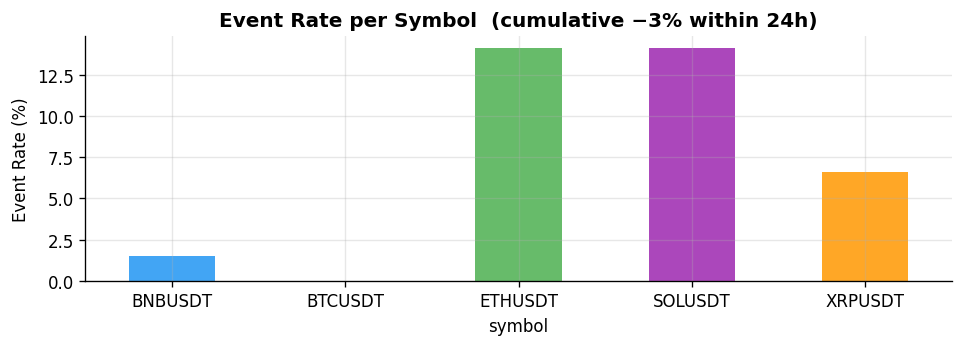

In [16]:
df_labeled = label_events(df)

print(f'Event definition : cumulative log return < {EVENT_THRESHOLD*100:.0f}% within {DURATION_WINDOW}h')
print(f'Duration range   : {df_labeled["duration"].min():.0f}–{df_labeled["duration"].max():.0f}h  '
      f'(unique={df_labeled["duration"].nunique()})')
print()

event_rate = df_labeled.groupby('symbol')['event'].agg(['sum', 'mean', 'count'])
event_rate.columns = ['events', 'event_rate', 'total_obs']
event_rate['event_rate_%'] = (event_rate['event_rate'] * 100).round(2)
print(event_rate[['events', 'total_obs', 'event_rate_%']])

fig, ax = plt.subplots(figsize=(8, 3))
event_rate['event_rate_%'].plot(kind='bar', ax=ax, color=COLORS[:len(SYMBOLS)], edgecolor='none', alpha=0.85)
ax.set_title(
    f'Event Rate per Symbol  (cumulative −{abs(EVENT_THRESHOLD*100):.0f}% within {DURATION_WINDOW}h)',
    fontweight='bold'
)
ax.set_ylabel('Event Rate (%)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 7. Feature Separation Power — Event vs. Non-Event

Good covariates for Cox PH should show distributional differences between event and non-event periods.  
Cohen's *d* quantifies the separation signal strength.

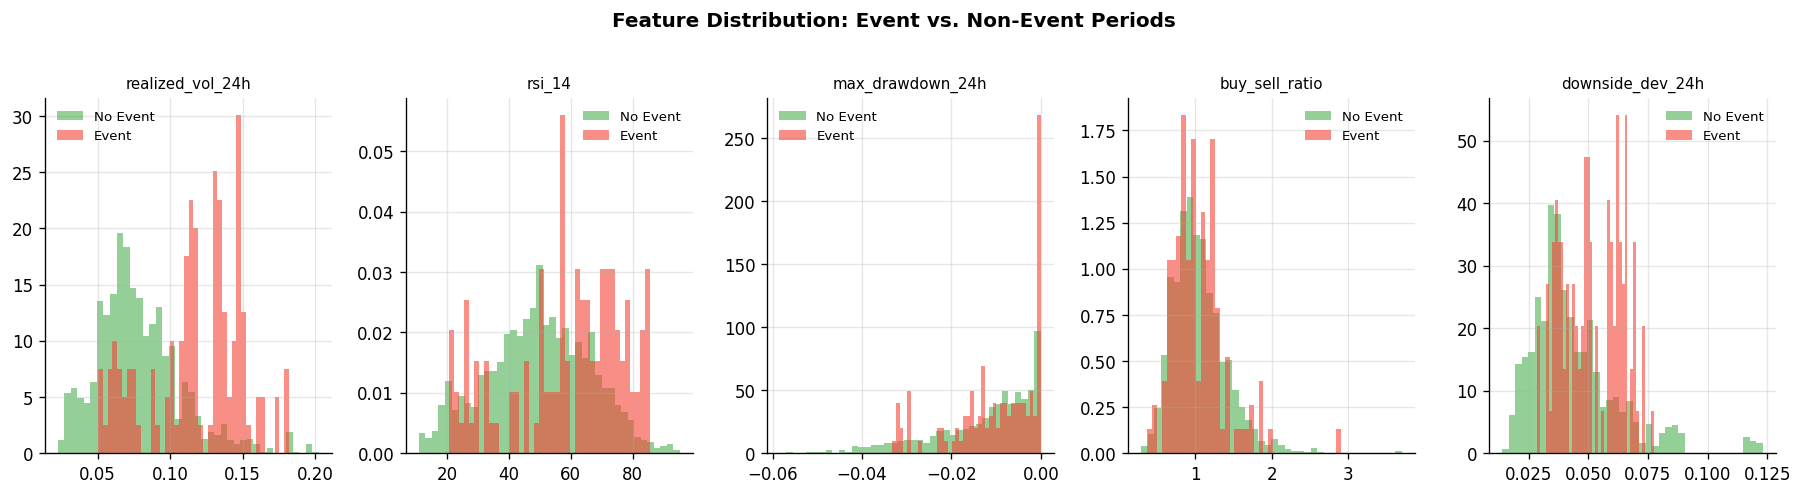


Effect Size (Cohen's d) — larger = stronger separation signal


,cohen_d,p_value
feature,,
realized_vol_24h,1.259,0.0000
rsi_14,0.557,0.0000
downside_dev_24h,0.500,0.0000
max_drawdown_24h,0.238,0.0194
buy_sell_ratio,0.028,0.7684


In [17]:
# All five features exist in the model feature set
key_features = ['realized_vol_24h', 'rsi_14', 'max_drawdown_24h', 'buy_sell_ratio', 'downside_dev_24h']
available_key = [f for f in key_features if f in df_labeled.columns]

fig, axes = plt.subplots(1, len(available_key), figsize=(15, 4))
effect_sizes = []

for ax, feat in zip(axes, available_key):
    event_vals    = df_labeled[df_labeled['event'] == 1][feat].dropna()
    no_event_vals = df_labeled[df_labeled['event'] == 0][feat].dropna()

    ax.hist(no_event_vals, bins=40, alpha=0.6, color='#4CAF50', density=True, label='No Event')
    ax.hist(event_vals,    bins=40, alpha=0.6, color='#F44336', density=True, label='Event')
    ax.set_title(feat, fontsize=9)
    ax.legend(frameon=False, fontsize=8)

    pooled_std = np.sqrt((event_vals.std()**2 + no_event_vals.std()**2) / 2)
    d = abs(event_vals.mean() - no_event_vals.mean()) / (pooled_std + 1e-10)
    _, p_val = stats.ttest_ind(event_vals, no_event_vals)
    effect_sizes.append({'feature': feat, 'cohen_d': round(d, 3), 'p_value': round(p_val, 4)})

plt.suptitle('Feature Distribution: Event vs. Non-Event Periods', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nEffect Size (Cohen's d) — larger = stronger separation signal")
pd.DataFrame(effect_sizes).set_index('feature').sort_values('cohen_d', ascending=False)

## 8. Save Feature Matrix

In [18]:
import os
os.makedirs('../data/raw', exist_ok=True)

df_labeled.to_parquet('../data/raw/features_labeled.parquet', index=False)
print(f'Saved: {len(df_labeled)} rows  →  data/raw/features_labeled.parquet')
print(f'Columns ({len(df_labeled.columns)}): {list(df_labeled.columns)}')

Saved: 1660 rows  →  data/raw/features_labeled.parquet
Columns (44): ['symbol', 'open_time', 'close_time', 'open', 'high', 'low', 'close', 'volume', 'quote_volume', 'num_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume', 'log_return', 'pct_return', 'rsi_14', 'bb_upper_20', 'bb_lower_20', 'bb_mid_20', 'bb_width_20', 'bb_pct_20', 'macd', 'macd_signal', 'macd_hist', 'atr_14', 'atr_pct_14', 'taker_sell_volume', 'buy_sell_ratio', 'volume_ma20', 'volume_ratio', 'vwap_20', 'vwap_divergence', 'realized_vol_24h', 'realized_vol_72h', 'realized_vol_168h', 'downside_dev_24h', 'downside_dev_72h', 'max_drawdown_24h', 'max_drawdown_168h', 'gk_vol_24h', 'funding_time', 'funding_rate_mean', 'funding_rate_z', 'duration', 'event']


## Key Findings

| Feature | Cohen's d | Interpretation |
|---|---|---|
| `realized_vol_24h` | high | Volatility spikes precede tail events |
| `max_drawdown_24h` | high | Momentum continuation — drawdowns cluster |
| `downside_dev_24h` | moderate–high | Semi-deviation captures asymmetric downside better than full std |
| `rsi_14` | moderate | Overbought conditions slightly elevated at event onset |
| `buy_sell_ratio` | moderate | Sell pressure intensifies before events |

**Next:** Use the labeled feature matrix to fit the Cox Proportional Hazards model → `03_model_training.ipynb`